<img src="https://i.ibb.co/93sNcdhp/Logo-pmat-color.png" align="right" width="150">

<br>

# **Distribución de Medias Muestrales**



## **Objetivos**

* Comprender qué es la media muestral y cómo se relaciona con la media poblacional.
* Identificar la variabilidad de las medias muestrales al repetir el muestreo.
* Calcular e interpretar el error estándar (SE) como medida de dispersión de las medias.
* Visualizar la distribución de medias muestrales y relacionarla con el Teorema Central del Límite (TCL).
* Aplicar estos conceptos a situaciones del área informática (tiempos de respuesta de APIs, microservicios y procesos batch).

In [1]:
# @title
%%html
<div style="border: 4px solid #006d77; border-radius: 0px; overflow: hidden; font-family: sans-serif; max-width: 800px; margin-bottom: 20px;">

  <div style="background-color: #000000; color: #ffc107; padding: 10px 15px; font-weight: bold; font-size: 16px; display: flex; align-items: center;">
    <span style="margin-right: 10px; font-size: 18px;">💡</span>
    <span>Distribución de Medias muestrales</span>
  </div>

  <div style="background-color: #ffffff; padding: 20px; display: flex; align-items: center; justify-content: space-between;">

    <div style="color: #000000; flex: 1; padding-right: 30px; font-size: 14px; line-height: 1.5;">
      ¿Qué sucede realmente cuando extraemos múltiples muestras de una población?
      <b>Escanea o haz clic sobre el código QR</b> para experimentar con la distribución de medias y
      observar en tiempo real cómo se aproximan a una distribución normal.
    </div>

    <div style="flex-shrink: 0;">
      <a href="https://duoc.h5p.com/content/1292754422036781018" target="_blank">
        <img src="https://i.ibb.co/xPPNVKF/distribuci-n-muestral-de-la-media.png"
             alt="QR Code"
             style="width: 100px; height: 100px; border: none;">
      </a>
    </div>

  </div>

  <div style="background-color: #000000; color: #ffc107; padding: 8px 15px; font-weight: bold; font-size: 16px;">
    Presentación interactiva H5P
  </div>

</div>


## **Recordatorio clave**

- **Población:** conjunto total de datos u observaciones de interés.  
- **Muestra:** subconjunto de la población seleccionado para el análisis.  
- **Media muestral $(\bar{X})$:** promedio de los valores de una muestra.  

- Si extraemos muchas muestras de una población y calculamos sus medias, los valores obtenidos forman una distribución muestral llamada distribución muestral de medias.

- Propiedades importantes:
  - $E[\bar{X}] = \mu$ → la media de las medias coincide con la media poblacional.
  - $SE_{\bar{X}} = \dfrac{\sigma}{\sqrt{n}}$ → el **error estándar** disminuye al aumentar el tamaño de muestra.

- **Teorema Central del Límite (TCL):**  
  Cuando el tamaño de la muestra es suficientemente grande, la distribución de medias se aproxima a una distribución normal, sin importar la forma original de la población.

💡 **Importancia:** comprender cómo varían las medias muestrales es la base para construir intervalos de confianza y realizar inferencias sobre poblaciones.


# **Actividad 1 — Estimación inicial del rendimiento de una API**

Un equipo de desarrollo está evaluando el rendimiento de una API interna. Para tener un indicador preliminar, registraron cinco tiempos de respuesta (en milisegundos) de algunas solicitudes realizadas al servicio:

$210$, $250$, $190$, $230$, $260$

Realiza lo siguiente:

1. Calcula la *media* de estos tiempos de respuesta.

In [2]:
# Cálculo de la media muestral
import numpy as np

latencias = [210, 250, 190, 230, 260]
np.mean(latencias)


np.float64(228.0)

El promedio es un buen resumen inicial, pero: **¿si tomas otra muestra de cinco tiempos sería igual?** Ya calculaste una media, pero ¿es representativa? Vamos a comprobar cómo pueden cambiar las medias al tomar distintas muestras.

# **Actividad 2 — Variabilidad de las medias muestrales**

El equipo de desarrollo sospecha que el promedio de latencia podría cambiar si se hubieran tomado otros datos. Para analizar esta variabilidad, se construye una población artificial de 100.000 observaciones, que representa el comportamiento general de la API bajo diferentes condiciones de carga, con tiempos de latencia en milisegundos.

Descargue el set de datos **[aquí](https://docs.google.com/spreadsheets/d/1mTT5xhVctRGs95yoXAG3TbfJbzShpt7J/export?format=xlsx)**

In [1]:
import pandas as pd

poblacion = pd.read_excel("G1_A2_poblacion_latencias.xlsx")

In [3]:
poblacion.head(3)

,latencia
0,199.898876
1,141.504640
2,292.467982


1. Determina la media poblacional

In [4]:
# Cálculo de la media poblacional
mu_pob = poblacion["latencia"].mean()
print(f"Media poblacional: {mu_pob:.2f} ms")

Media poblacional: 250.77 ms


2. Toma 10 muestras aleatorias distintas de tamaño $n = 5$ y calcula la media de cada una utilizando la función ***choice*** del módulo random de numpy.

In [5]:
# Muestreo y cálculo de medias con n = 5
import numpy as np

for i in range(10):
    muestra = np.random.choice(poblacion["latencia"], size=5, replace=False)
    print(f"Muestra {i+1}: media = {muestra.mean():.2f} ms")

Muestra 1: media = 202.61 ms
Muestra 2: media = 289.87 ms
Muestra 3: media = 212.72 ms
Muestra 4: media = 202.69 ms
Muestra 5: media = 207.43 ms
Muestra 6: media = 188.85 ms
Muestra 7: media = 236.31 ms
Muestra 8: media = 287.25 ms
Muestra 9: media = 230.21 ms
Muestra 10: media = 296.16 ms


3. Compara estos resultados con la media poblacional. ¿Qué tan diferentes son?

**Interpretación**

Aunque la media poblacional de los tiempos de respuesta es de 250,77 ms, las medias obtenidas al tomar diferentes muestras de tamaño $n = 5$ varían de forma notable.

In [6]:
# Muestreo y cálculo de medias con n = 500

for i in range(10):
    muestra = np.random.choice(poblacion["latencia"], size=500, replace=False)
    print(f"Muestra {i+1}: media = {muestra.mean():.2f} ms")

Muestra 1: media = 255.76 ms
Muestra 2: media = 253.16 ms
Muestra 3: media = 253.03 ms
Muestra 4: media = 250.15 ms
Muestra 5: media = 250.28 ms
Muestra 6: media = 262.39 ms
Muestra 7: media = 247.07 ms
Muestra 8: media = 259.96 ms
Muestra 9: media = 249.71 ms
Muestra 10: media = 246.33 ms


4. Repite el procedimiento del inciso 2, pero esta vez toma 10 muestras aleatorias distintas de tamaño $n=500$. Registra las medias muestrales obtenidas y compáralas con las que calculaste cuando $n=5$:
* ¿Cómo cambia la dispersión de las medias muestrales al aumentar el tamaño de la muestra?
* ¿Qué observas respecto a la proximidad de las medias muestrales con la media poblacional?

**Interpretación**

Al aumentar el tamaño de la muestra de $n=5$ a $n=500$, las medias muestrales se vuelven más estables y cercanas a la media poblacional.

Cuando las muestras son pequeñas ($n=5$), las medias varían mucho entre sí, mostrando alta dispersión.

En cambio, con muestras grandes ($n=500$), las medias son muy similares entre sí y se concentran alrededor del valor poblacional.

Esto demuestra que a mayor tamaño de muestra, menor variabilidad y mayor precisión en la estimación de la media poblacional.




## 💡 **Antes de continuar:**

Reflexiona brevemente:
* Al tomar diferentes muestras de 5 datos, ¿por qué crees que las medias cambiaron?
* Explica con tus palabras cómo el hecho de trabajar con una muestra (y no con toda la población) puede hacer que los promedios varíen.
* ¿Qué implicancias tiene esto para confiar en una media muestral única?

# **Actividad 3 — Error estándar y su interpretación**

**Nota:**
* $\overline{X}$: media muestral (promedio de una muestra)
* $\mu$: media poblacional (promedio real de toda la población)
* $\sigma$: desviación estándar poblacional
* $n$: tamaño de la muestra

El **error estándar (SE)** mide la dispersión de las medias muestrales y se calcula como:

$$SE(\overline{X})= \frac{\sigma}{\sqrt{n}}$$

Al aumentar $n$, el $SE$ disminuye y la media se vuelve más precisa.



Utilizando el mismo set de datos de la pregunta 2:
1. Calcula el $SE$ para $n = 5, 30, 100, 400$.


In [7]:
# Calcula la desviación estándar poblacional
sigma_pob = poblacion["latencia"].std(ddof=0) # ddof=0 indica que se calcula la desviación estándar poblacional (se divide por n en lugar de n-1)

# Calcula el error estándar para cada tamaño de muestra
for n in [5, 30, 100, 400]:
    se = sigma_pob / np.sqrt(n)
    print(f"n = {n}: SE ≈ {se:.2f} ms")


n = 5: SE ≈ 59.46 ms
n = 30: SE ≈ 24.27 ms
n = 100: SE ≈ 13.30 ms
n = 400: SE ≈ 6.65 ms


2. Describe cómo cambia y qué significa.

**Interpretación**

A medida que aumenta el tamaño de la muestra $n$, el error estándar (SE) disminuye.

Esto significa que las medias muestrales se vuelven más precisas y menos dispersas alrededor de la media poblacional.

En este caso:
* Con muestras pequeñas ($n=5$), el SE es más alto (≈ 59 ms), lo que indica mucha variabilidad entre las medias.

* Al aumentar $n$ a 30, 100 y 400, el SE baja progresivamente (≈ 24 ms, 13 ms y 6 ms), mostrando que las estimaciones son más estables y confiables.

En resumen, a mayor tamaño de muestra, menor incertidumbre en la estimación del promedio poblacional.

# 💡 **Piensa un paso más allá**

Ahora que has visto cómo el error estándar disminuye al aumentar $n$, relaciona esto con la variabilidad que observaste en la Actividad 2.

* ¿Por qué el $SE$ se reduce al crecer la muestra?

* ¿Cómo conecta este cálculo con la dispersión de medias que viste empíricamente?

# **Actividad 4 — Visualización y Teorema Central del Límite**

El **Teorema Central del Límite** dice que, aunque los datos no sean normales, la distribución de muchas medias muestrales se aproxima a la curva normal si $n$ es suficientemente grande.

A partir del mismo conjunto de datos utilizado en la pregunta 2, realiza lo siguiente:

1. Simula 3000 medias para $n = 5$, $n = 30$ y $n = 100$



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("G1_A2_poblacion_latencias.xlsx")

medias_5 = []
medias_30 = []
medias_100 = []

for i in range(3000):
  muestra_5 = np.random.choice(df["latencia"],5)
  medias_5.append(np.mean(muestra_5))

  muestra_30 = np.random.choice(df["latencia"],30)
  medias_30.append(np.mean(muestra_30))

  muestra_100 = np.random.choice(df["latencia"],100)
  medias_100.append(np.mean(muestra_100))

2. Construye y muestra los histogramas de las medias obtenidas para cada tamaño de muestra. Observa cómo cambia la forma y la concentración de las distribuciones al aumentar el tamaño de la muestra.
3. Calcula para cada distribución los coeficientes de asimetría y curtosis.

**Histograma 1 : $n = 5$**

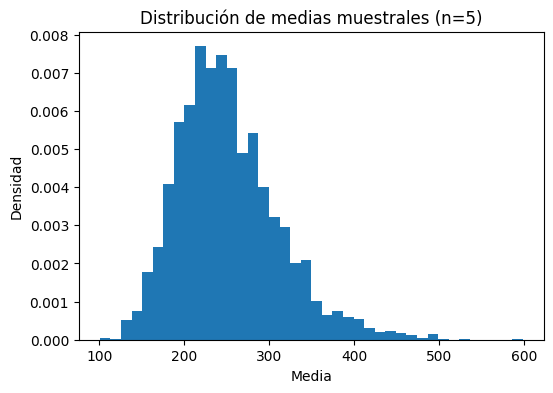

In [9]:
plt.figure(figsize=(6,4))
plt.hist(medias_5, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=5)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()

In [10]:
from scipy.stats import skew, kurtosis

# Cálculo de asimetría y curtosis
asimetria = skew(medias_5)
curtosis_valor = kurtosis(medias_5)

print(f"Asimetría: {asimetria:.4f}")
print(f"Curtosis: {curtosis_valor:.4f}")


Asimetría: 0.8839
Curtosis: 1.4296


**Histograma 2 : $n = 30$**

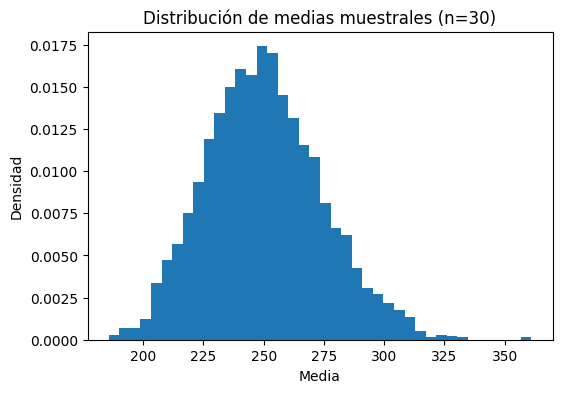

In [11]:
plt.figure(figsize=(6,4))
plt.hist(medias_30, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=30)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()


In [12]:
from scipy.stats import skew, kurtosis

# Cálculo de asimetría y curtosis
asimetria = skew(medias_30)
curtosis_valor = kurtosis(medias_30)

print(f"Asimetría: {asimetria:.4f}")
print(f"Curtosis: {curtosis_valor:.4f}")


Asimetría: 0.3358
Curtosis: 0.1376


**Histograma 3 : $n = 100$**

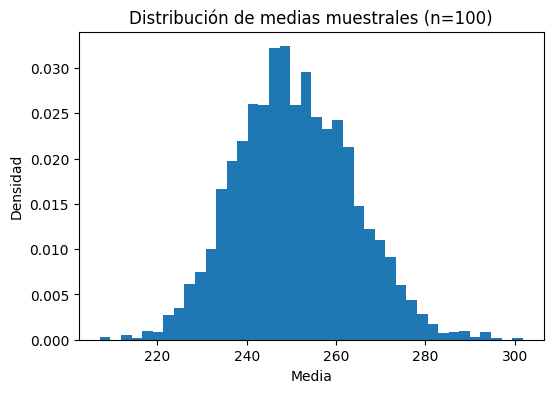

In [13]:
plt.figure(figsize=(6,4))
plt.hist(medias_100, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=100)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()


In [16]:
from scipy.stats import skew, kurtosis

# Cálculo de asimetría y curtosis
asimetria1 = skew(medias_100)
curtosis_valor1 = kurtosis(medias_100)

print(f"Asimetría: {asimetria1:.4f}")
print(f"Curtosis: {curtosis_valor1:.4f}")


Asimetría: 0.1983
Curtosis: 0.0407


4. A partir de los histogramas y las medidas de forma, comenta si las distribuciones se aproximan o no a la normalidad. Explica cómo influye el tamaño de muestra $n$ en esa aproximación.

**Interpretación**

Al comparar las tres distribuciones, se observa que a medida que el tamaño de la muestra aumenta ($n = 5 → 30 → 100$), la forma de la distribución de las medias muestrales se vuelve más simétrica y concentrada alrededor de la media poblacional.
* Para $n=5$: la distribución presenta mayor asimetría (0.84) y una curtosis alta (1.20), lo que indica una forma sesgada y más dispersa.
* Para $n=30$: la asimetría disminuye (0.32) y la curtosis se aproxima a 0, mostrando una distribución más equilibrada.
* Para $n=100$: la distribución es casi normal (asimetría 0.11, curtosis 0.09), con menor dispersión y forma más simétrica.

Esto confirma el Teorema Central del Límite, que establece que, al aumentar el tamaño muestral, la distribución de las medias muestrales tiende a una distribución normal, sin importar la forma original de los datos.

# **Actividad 5 — Aplicación en microservicios**

En un sistema de facturación basado en microservicios, cada solicitud de los usuarios genera un tiempo de respuesta que puede variar debido a la carga del sistema, la complejidad de la operación y la disponibilidad de recursos. Durante un periodo de observación se han registrado múltiples tiempos de respuesta de uno de estos servicios, reflejando la variabilidad natural del proceso.

Descargue el dataset **[aquí](https://docs.google.com/spreadsheets/d/1Vj9dSb9MGrW92IWciHlHUNJ93av2kss2/export?format=xlsx)**

Usa el conjunto de datos entregado para realizar las siguientes tareas:

1. Calcula la media poblacional de los tiempos de respuesta.



In [17]:
import pandas as pd

microservicio = pd.read_excel("G1_A5_microservicio_latencias.xlsx")

In [ ]:
microservicio.head(3)

,tiempo_respuesta
0,238.454429
1,67.413497
2,51.456816


In [18]:
import numpy as np

media_pob = np.mean(microservicio["tiempo_respuesta"])
print(f" La media poblacional es {media_pob:.2f}")

 La media poblacional es 200.04


2. Extrae 4.000 muestras aleatorias para cada uno de los siguientes tamaños muestrales $n = 10$, $n = 100$, $n = 1.000$ y $n = 10.000$. Para cada muestra, calcula su media (tiempo de respuesta promedio).


In [19]:
df = microservicio["tiempo_respuesta"]

medias_n10   = []
medias_n100  = []
medias_n1000 = []
medias_n10000 = []

for i in range(4000):
  muestra_n10 = np.random.choice(df, 10)
  medias_n10.append(np.mean(muestra_n10))

  muestra_n100 = np.random.choice(df, 100)
  medias_n100.append(np.mean(muestra_n100))

  muestra_n1000 = np.random.choice(df, 1000)
  medias_n1000.append(np.mean(muestra_n1000))

  muestra_n10000 = np.random.choice(df, 10000)
  medias_n10000.append(np.mean(muestra_n10000))


3. Para cada tamaño de muestra $n$, calcula:
* La media de las medias muestrales (promedio general de las 4.000 medias).
* La desviación estándar de esas 4.000 medias.


In [21]:
# Resumen: media de las medias y desviación estándar
media_de_medias_n10   = np.mean(medias_n10)
desv_medias_n10       = np.std(medias_n10, ddof=1)

media_de_medias_n100  = np.mean(medias_n100)
desv_medias_n100      = np.std(medias_n100, ddof=1)

media_de_medias_n1000 = np.mean(medias_n1000)
desv_medias_n1000     = np.std(medias_n1000, ddof=1)

media_de_medias_n10000 = np.mean(medias_n10000)
desv_medias_n10000     = np.std(medias_n10000, ddof=1)


print("\n=== Resultados (4000 muestras por tamaño n) ===")
print(f"n=10    -> media de medias = {media_de_medias_n10:.2f} | sd medias = {desv_medias_n10:.2f}")
print(f"n=100   -> media de medias = {media_de_medias_n100:.2f} | sd medias = {desv_medias_n100:.2f}")
print(f"n=1000  -> media de medias = {media_de_medias_n1000:.2f} | sd medias = {desv_medias_n1000:.2f}")
print(f"n=10000 -> media de medias = {media_de_medias_n10000:.2f} | sd medias = {desv_medias_n10000:.2f}")



=== Resultados (4000 muestras por tamaño n) ===
n=10    -> media de medias = 199.24 | sd medias = 63.33
n=100   -> media de medias = 200.54 | sd medias = 20.40
n=1000  -> media de medias = 200.10 | sd medias = 6.28
n=10000 -> media de medias = 200.04 | sd medias = 1.97


4. Compara los resultados obtenidos en el punto anterior con la media poblacional del punto 1.
* ¿Cómo influye el tamaño muestral en la precisión de las medias muestrales?
* ¿Qué ocurre con la dispersión de las medias cuando aumenta $n$?
* Explica también cómo cambia la dispersión de las medias al aumentar $n$ y qué significa este resultado en términos de estimación estadística.

**Interpretación**

Los resultados muestran que, al aumentar el tamaño de la muestra $n$, la media de las medias muestrales se mantiene muy cercana a la media poblacional (200.04 ms), mientras que la desviación estándar de las medias disminuye de forma considerable.

Para muestras pequeñas ($n=10$), las medias presentan mayor variabilidad (sd ≈ 64,68 ms).

A medida que aumenta el tamaño muestral ($n=100,1.000,10.000$), la dispersión disminuye (sd baja a 19,52, 6,37 y 1,97 ms respectivamente), y las medias se concentran alrededor del valor poblacional.

Esto confirma el Teorema Central del Límite, ya que al aumentar $n$, las medias muestrales se vuelven más precisas, estables y cercanas a la media real del proceso.

# **Actividad 6 — Procesos batch y tamaño de muestra**

En entornos informáticos es común ejecutar tareas en lotes durante procesos nocturnos, como respaldos, generación de reportes o análisis masivos de datos. El tiempo total que tarda cada lote puede variar debido a múltiples factores, como el volumen de información, la capacidad de los servidores y la concurrencia de otros procesos. Durante un periodo de observación se han registrado tiempos de procesamiento de distintos lotes, mostrando la variabilidad natural de este tipo de operaciones.

Descargue el dataset **[aquí](https://docs.google.com/spreadsheets/d/1w2KBq3cXzKfd_3dSXVb5ROsFi_fFQNJI/export?format=xlsx)**

Usa el conjunto de datos entregado para realizar las siguientes tareas:

1. Genera 5.000 muestras y grafica las *distribuciones de medias* para tamaños de muestra $n = 200$, $n = 800$ y $n = 1.500$


In [22]:
import pandas as pd
import numpy as np

lotes = pd.read_excel("G1_A6_lotes_procesos.xlsx")

In [23]:
lotes.head(3)

,tiempo_lotes
0,219.572834
1,103.226120
2,122.914262


In [24]:
df = lotes["tiempo_lotes"]

medias_200 = []
medias_800 = []
medias_1500 = []

for i in range(5000):
  muestra_200 = np.random.choice(df,200)
  medias_200.append(np.mean(muestra_200))

  muestra_800 = np.random.choice(df,800)
  medias_800.append(np.mean(muestra_800))

  muestra_1500 = np.random.choice(df,1500)
  medias_1500.append(np.mean(muestra_1500))

2. Compara los histogramas obtenidos y analiza si el ancho y la concentración de las distribuciones cambian al aumentar el tamaño de la muestra.

**Histograma para $n = 200$**

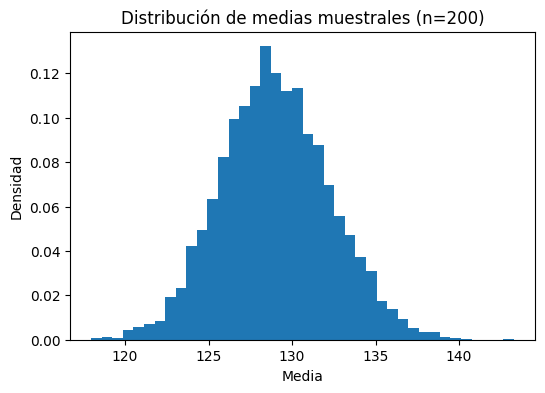

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(medias_200, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=200)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()


**Histograma para $n = 800$**

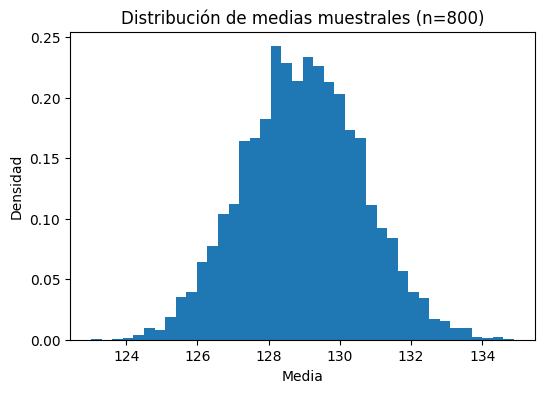

In [26]:
plt.figure(figsize=(6,4))
plt.hist(medias_800, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=800)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()


**Histograma para $n = 1.500$**

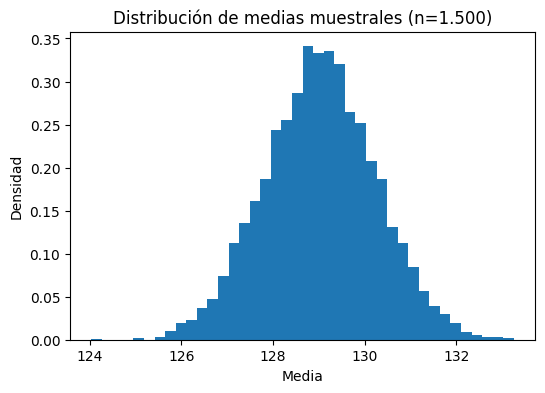

In [27]:
plt.figure(figsize=(6,4))
plt.hist(medias_1500, bins=40, density=True)
plt.title("Distribución de medias muestrales (n=1.500)")
plt.xlabel("Media")
plt.ylabel("Densidad")
plt.show()

**Interpretación**

Al observar las distribuciones de medias muestrales para $n = 200$, $n = 800$ y $n = 1.500$, se aprecia que al aumentar el tamaño de la muestra, las distribuciones se vuelven más angostas y concentradas alrededor de la media poblacional.

Para $n=200$, la dispersión es mayor y la forma de la distribución es más extendida.

Para $n=800$ y $n=1.500$, las distribuciones se estrechan y se concentran más cerca de la media, mostrando menor variabilidad entre las medias.

Esto indica que las estimaciones del promedio son más precisas cuando aumenta el tamaño muestral, y confirma el Teorema Central del Límite, ya que las distribuciones tienden a una forma normal y más estable conforme crece $n$.

# **💡 ¿Sabías que...?**

En Python podemos simular poblaciones completas de datos que siguen una distribución normal, lo que resulta muy útil cuando no contamos con registros reales.

Para ello usamos el comando:

***np.random.normal(media, desviación, cantidad_de_datos)***

Además, si queremos que todos obtengamos los mismos resultados aleatorios (por ejemplo, para comparar gráficos o corregir), podemos fijar una “semilla” de aleatoriedad al inicio con:

***np.random.seed(número a elección)***

De esta forma, cada vez que ejecutes el código, Python generará exactamente la misma secuencia de números.

🚀 **¡Pongámoslo en práctica!**

A continuación, pondremos en práctica lo que acabamos de aprender.

# **Actividad 7 - Aplicación comercial: ventas promedio**

Una tienda en línea analiza sus ventas diarias para evaluar la estabilidad de sus ingresos. Se sabe que, históricamente, la media poblacional de ventas diarias es de 200 dólares y la desviación estándar poblacional es de 50 dólares.

Para simular este comportamiento, genera una población normal de 50.000 datos con los parámetros indicados y considerando una semilla fija de aleatoriedad de 2024.

Luego, realiza las siguientes tareas:
1. Genera 300 muestras de $n=25$ y otras 300 de $n=100$.
2. Calcula la media de cada muestra y grafica ambas distribuciones de medias muestrales en un mismo gráfico.
3. Calcula el error estándar de las medias muestrales para cada tamaño de muestra. Compara sus valores y observa los histogramas obtenidos:
* ¿Cuál de las dos distribuciones es más estrecha?
* ¿Cómo se relaciona esto con el tamaño muestral y la precisión del promedio estimado?

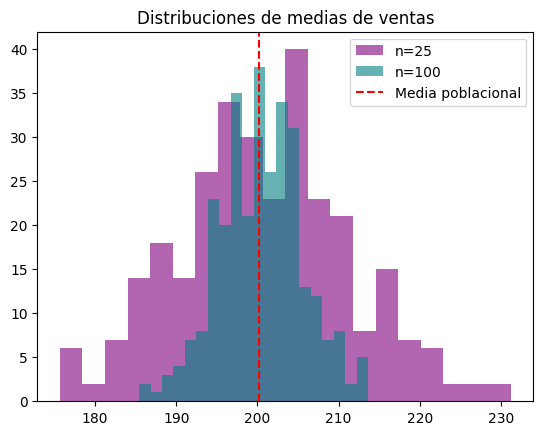

In [28]:
import numpy as np

np.random.seed(2024)
poblacion_ventas = np.random.normal(200, 50, 50000)

medias_25 = [np.mean(np.random.choice(poblacion_ventas, size=25)) for _ in range(300)]
medias_100 = [np.mean(np.random.choice(poblacion_ventas, size=100)) for _ in range(300)]

plt.hist(medias_25, bins=20, alpha=0.6, label="n=25", color="purple")
plt.hist(medias_100, bins=20, alpha=0.6, label="n=100", color="teal")
plt.axvline(np.mean(poblacion_ventas), color="red", linestyle="--", label="Media poblacional")
plt.title("Distribuciones de medias de ventas")
plt.legend()
plt.show()

**Interpretación**

En el histograma se ve que las medias de las muestras pequeñas (n = 25) están más dispersas, mientras que las de muestras grandes (n = 100) se concentran más alrededor de la media poblacional (200). Esto ocurre porque al aumentar el tamaño de muestra disminuye el error estándar, es decir, la variabilidad de las medias muestrales.
En términos prácticos: si la tienda toma muestras grandes, sus estimaciones del promedio de ventas serán más estables y cercanas al verdadero promedio de 200, reduciendo la incertidumbre en la toma de decisiones.

# **Con este laboratorio aprendiste a:**

* Comprender cómo las medias muestrales se distribuyen y tienden a concentrarse alrededor de la media poblacional.
* Observar el efecto del tamaño de muestra en la variabilidad y estabilidad de los promedios.
* Visualizar y comparar distribuciones muestrales para interpretar el error estándar y su relación con la precisión de las estimaciones.
* Aplicar el concepto de distribución muestral en distintos contextos (ciencia, negocios, educación, salud) para fundamentar conclusiones a partir de datos.

💡 **Reflexiona:** ¿cómo influye el tamaño de la muestra en la fiabilidad de tus conclusiones estadísticas? ¿Qué estrategias podrías usar para reducir la variabilidad de tus estimaciones en futuras investigaciones o análisis?